# Load the Pickle file containing the created Network

In [15]:
import pickle
with open('dermnet_graph.pkl', 'rb') as f:
    G = pickle.load(f)

### Creating the Network

In [16]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import os

file_path = 'dermnet_graph.pkl'

if os.path.exists(file_path):
    with open(file_path, 'rb') as f:
        G_loaded = pickle.load(f)
    print(f"Successfully loaded graph with {G_loaded.number_of_nodes()} nodes.")
else:
    print(f"Error: {file_path} not found. Please run the export script first!")

print("\n Diagnostic Check")
for node_id, data in list(G_loaded.nodes(data=True))[:5]:
    name = data.get('name', 'N/A')
    label = data.get('label', 'N/A')
    print(f"Node ID: {node_id} | Name: {name} | Label: {label}")

import networkx as nx

def filter_network(G):
    blacklist_keywords = [
        'bisphenol', 'phthalate', 'pesticide', 'herbicide', 'lead', 
        'mercury', 'cadmium', 'arsenic', 'formaldehyde', 'benzene'
    ]
    
    nodes_to_remove = []
    for n, d in G.nodes(data=True):
        name = str(d.get('name', '')).lower()
        if any(key in name for key in blacklist_keywords):
            nodes_to_remove.append(n)
            
    print(f"Found {len(nodes_to_remove)} industrial/toxic nodes to prune.")
    
    G_clean = G.copy()
    G_clean.remove_nodes_from(nodes_to_remove)
    
    print(f"Filter Complete. New node count: {G_clean.number_of_nodes()}")
    return G_clean

G_loaded = filter_network(G_loaded)

Successfully loaded graph with 22193 nodes.

 Diagnostic Check
Node ID: 0 | Name: picoxystrobin | Label: Substance
Node ID: 1 | Name: picrasidine I | Label: Substance
Node ID: 2 | Name: 10,11-dihydro-10,11-dihydroxy-5H-dibenzazepine-5-carboxamide | Label: Substance
Node ID: 3 | Name: 10,12-octadecadienoic acid | Label: Substance
Node ID: 4 | Name: 10-(2-pyrazolylethoxy)camptothecin | Label: Substance
Found 177 industrial/toxic nodes to prune.
Filter Complete. New node count: 22016


### Calculating Basic Network Metrics

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import community.community_louvain as louvain

def run_global_metrics(G):
    print("--- Network Topology Metrics ---")
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    
    print(f"Total Nodes: {n_nodes}")
    print(f"Total Edges: {n_edges}")
    print(f"Average Degree: {(2 * n_edges) / n_nodes:.2f}")
    print(f"Network Density: {nx.density(G):.6f}")

    components = sorted(nx.connected_components(G), key=len, reverse=True)
    lcc = G.subgraph(components[0])
    print(f"Largest Connected Component (LCC): {len(lcc)} nodes")

    nodes = list(lcc.nodes())
    sample_size = min(500, len(nodes))
    path_lengths = []
    for _ in range(sample_size):
        u, v = np.random.choice(nodes, 2, replace=False)
        try:
            path_lengths.append(nx.shortest_path_length(lcc, u, v))
        except: continue
    
    print(f"Estimated Avg Path Length: {np.mean(path_lengths):.2f}")
    print(f"Average Clustering Coefficient: {nx.average_clustering(lcc):.4f}")

run_global_metrics(G_loaded)

--- Network Topology Metrics ---
Total Nodes: 22016
Total Edges: 81546
Average Degree: 7.41
Network Density: 0.000336
Largest Connected Component (LCC): 21920 nodes
Estimated Avg Path Length: 2.70
Average Clustering Coefficient: 0.0000


### D1 Creating the BiPartite Visualization

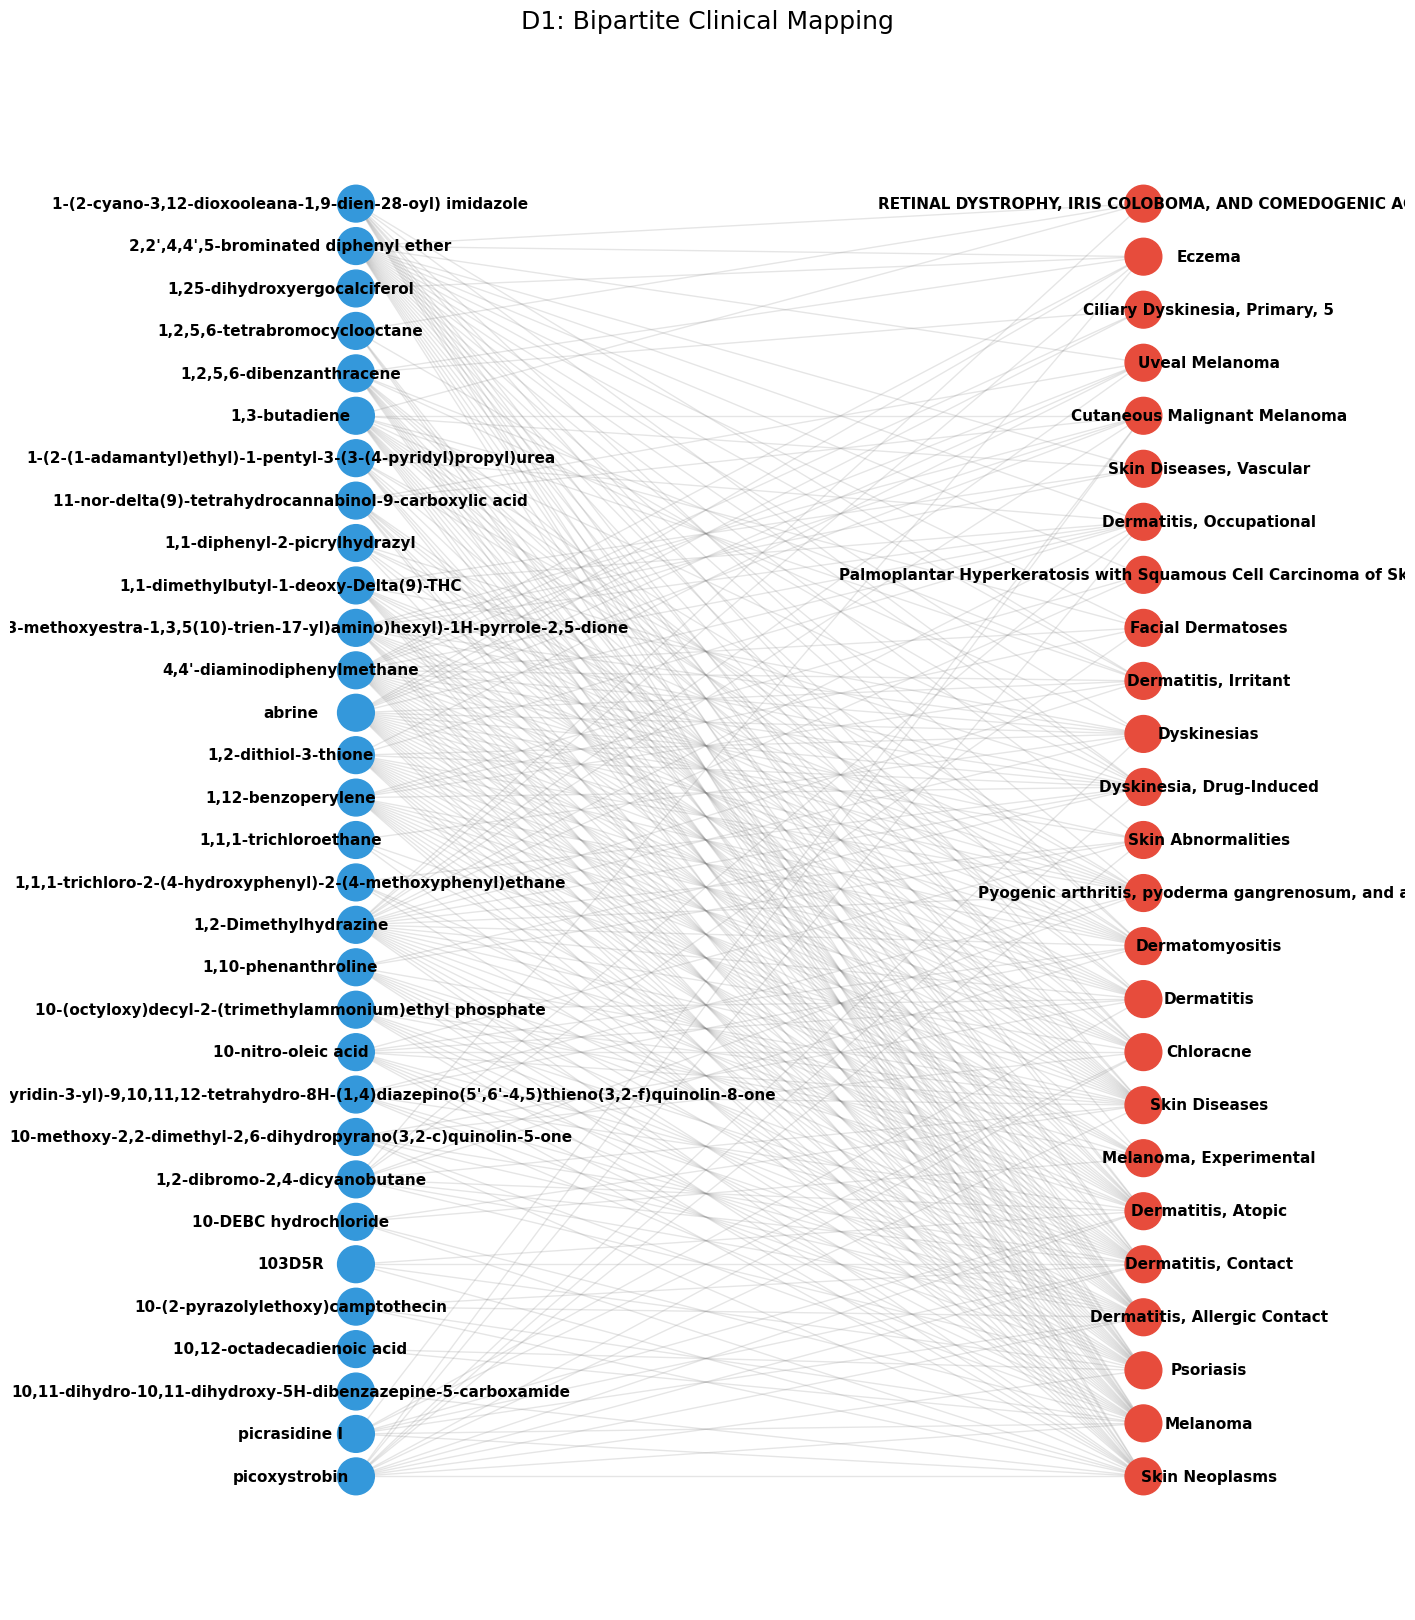

In [18]:
def plot_d1(G):
    conditions = [n for n, v in G.nodes(data=True) if v.get('label') == 'Condition']
    substances = [n for n, v in G.nodes(data=True) if v.get('label') == 'Substance']
    sampled_nodes = []
    selected_conds = conditions[:25]
    for c in selected_conds:
        sampled_nodes.append(c)
        neighbors = [n for n in G.neighbors(c) if n in substances]
        sampled_nodes.extend(neighbors[:3])
    subgraph = G.subgraph(sampled_nodes)
    left_nodes = [n for n in sampled_nodes if n in substances]
    pos = nx.bipartite_layout(subgraph, left_nodes)
    plt.figure(figsize=(18, 20))
    
    colors = ['#e74c3c' if G.nodes[n].get('label') == 'Condition' else '#3498db' for n in subgraph.nodes()]
    
    nx.draw_networkx_nodes(subgraph, pos, node_color=colors, node_size=700)
    nx.draw_networkx_edges(subgraph, pos, alpha=0.2, edge_color='gray')
    
    labels = {n: G.nodes[n].get('name', f"ID:{n}") for n in subgraph.nodes()}
    
    label_pos = {}
    for node, (x, y) in pos.items():
        label_pos[node] = (x - 0.15, y) if x < 0.5 else (x + 0.15, y)
    nx.draw_networkx_labels(subgraph, label_pos, labels=labels, 
                            font_size=11, font_weight='bold', 
                            horizontalalignment='center')
    
    plt.title("D1: Bipartite Clinical Mapping", fontsize=18, pad=30)
    plt.xlim(-1.6, 1.6)
    plt.axis('off')
    plt.show()
if 'G_loaded' in locals():
    plot_d1(G_loaded)

### D2 Finding Causal Clusters

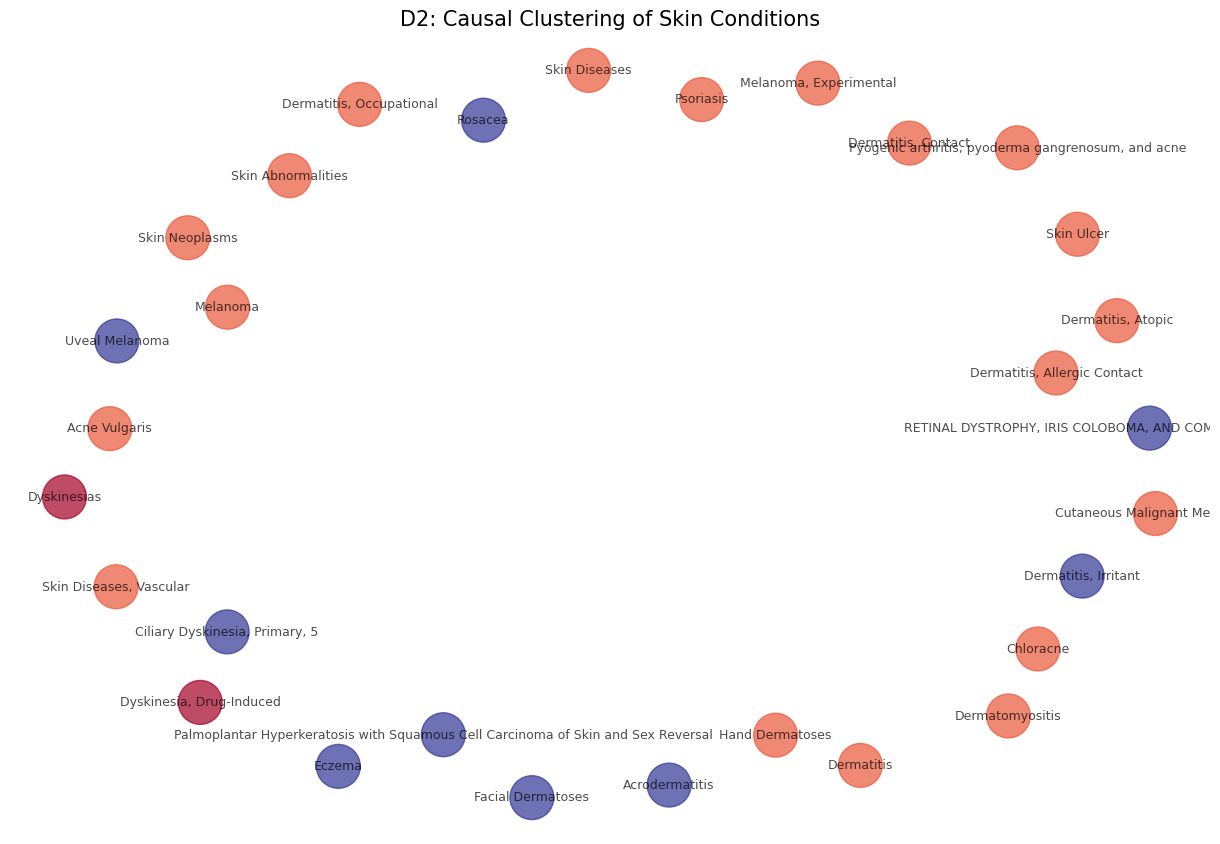

In [19]:
import community.community_louvain as louvain

def plot_d2_causal_clustering(G):
    conds = [n for n, v in G.nodes(data=True) if str(v.get('label')).lower() == 'condition']
    partition = louvain.best_partition(G.to_undirected())
    
    sampled_conds = conds[:30]
    subgraph = G.subgraph(sampled_conds)
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(subgraph, k=0.8)
    
    colors = [partition[n] for n in subgraph.nodes()]
    
    nx.draw(subgraph, pos, node_color=colors, cmap=plt.cm.RdYlBu,
            with_labels=True, labels={n: G.nodes[n].get('name', n) for n in subgraph.nodes()},
            node_size=1000, font_size=9, edge_color='gray', alpha=0.7)
    
    plt.title("D2: Causal Clustering of Skin Conditions", fontsize=15)
    plt.show()
plot_d2_causal_clustering(G_loaded)

### D3 Finding the "Hero" Substances which treat the most conditions

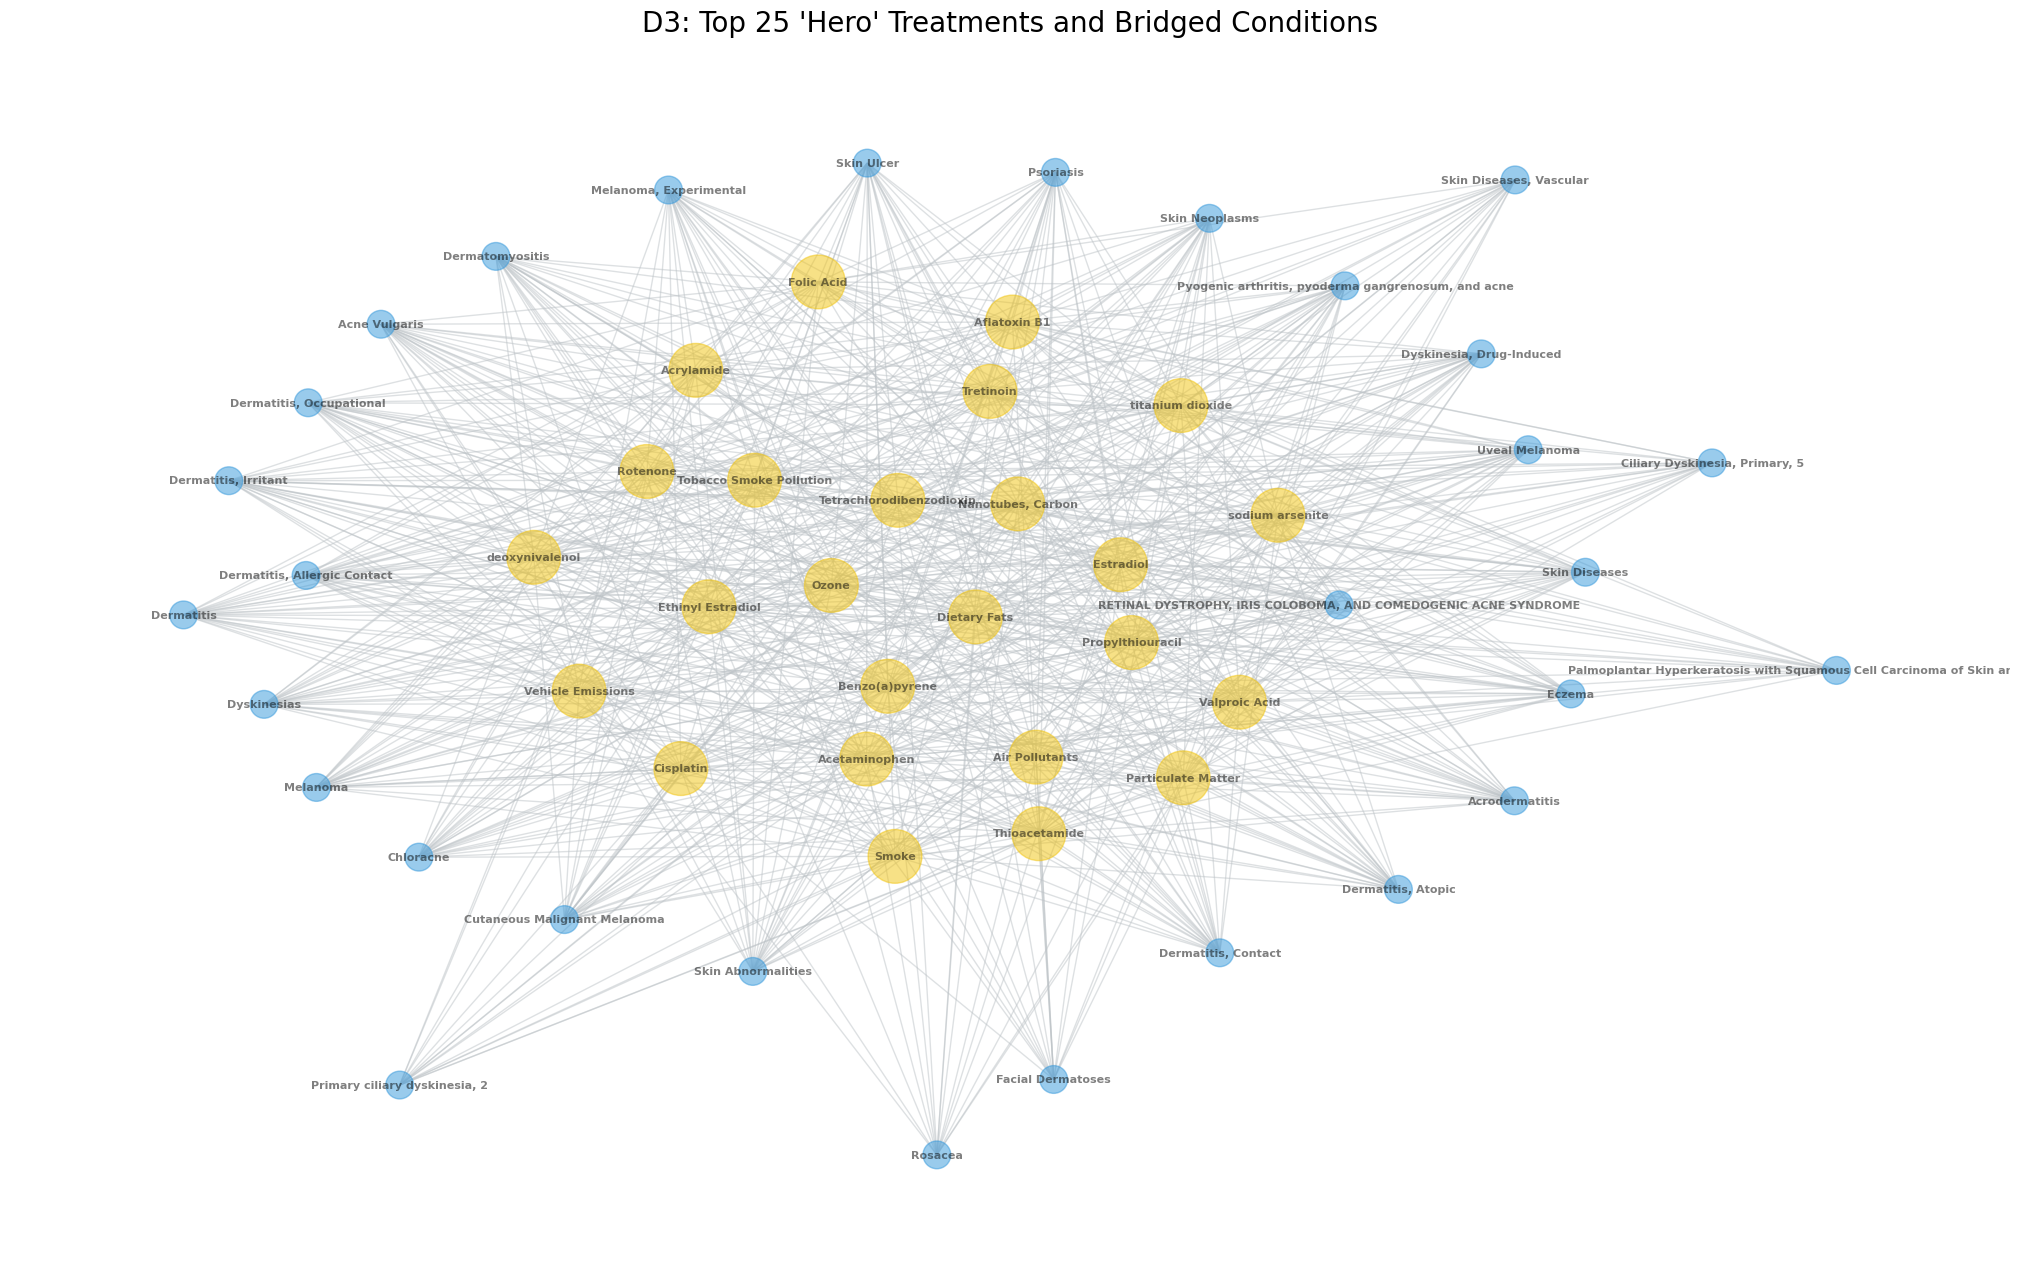

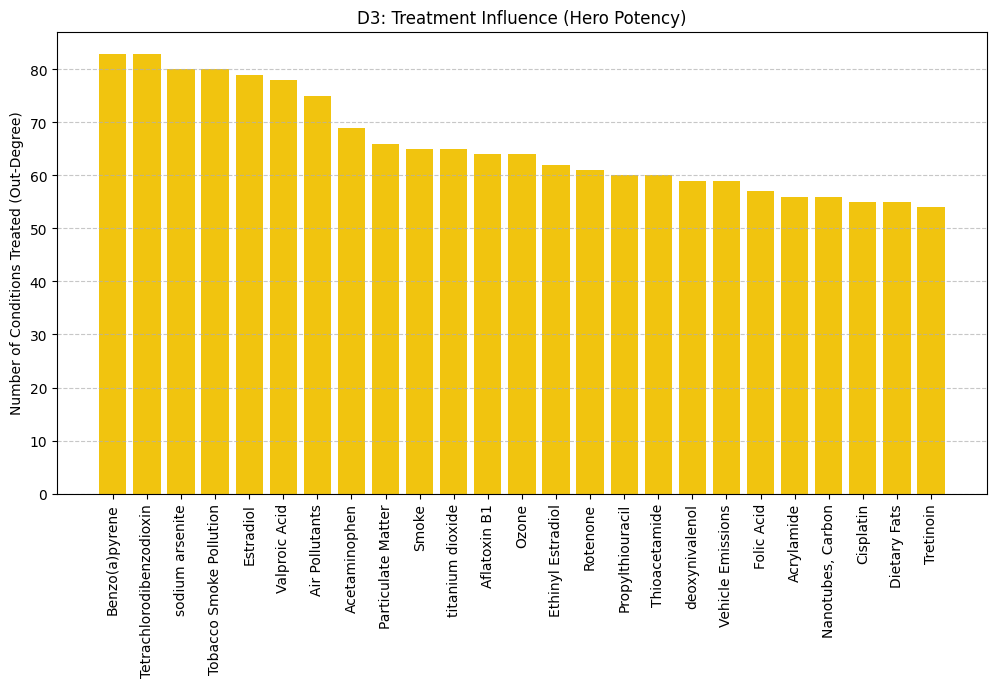

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_d3_hero_network(G, top_k=25):
    subs = [n for n, v in G.nodes(data=True) if str(v.get('label')).lower() == 'substance']
    
    hero_scores = {}
    for s in subs:
        cond_neighbors = [nbr for nbr in G.neighbors(s) 
                         if str(G.nodes[nbr].get('label')).lower() == 'condition']
        hero_scores[s] = len(cond_neighbors)
    
    top_heroes = sorted(hero_scores, key=hero_scores.get, reverse=True)[:top_k]
    
    relevant_conditions = []
    all_neighbors = []
    for h in top_heroes:
        neighbors = list(G.neighbors(h))
        all_neighbors.extend(neighbors)
        
    from collections import Counter
    counts = Counter(all_neighbors)
    bridge_conditions = [node for node, count in counts.items() if count >= 2]
    
    sampled_conds = bridge_conditions[:30]
    
    plot_nodes = top_heroes + sampled_conds
    subgraph = G.subgraph(plot_nodes)
    
    plt.figure(figsize=(20, 12))
    
    pos = nx.spring_layout(subgraph, k=1.5, iterations=50, seed=42)
    
    colors = []
    sizes = []
    for n in subgraph.nodes():
        if n in top_heroes:
            colors.append('#f1c40f') # Gold for Heroes
            sizes.append(1500)
        else:
            colors.append('#3498db') # Blue for Conditions
            sizes.append(400)
            
    nx.draw(subgraph, pos, node_color=colors, node_size=sizes, 
            with_labels=True, labels={n: G.nodes[n].get('name', n) for n in subgraph.nodes()},
            font_size=8, font_weight='bold', edge_color='#bdc3c7', alpha=0.5)
    
    plt.title(f"D3: Top {top_k} 'Hero' Treatments and Bridged Conditions", fontsize=20, pad=20)
    plt.show()

    hero_names = [G_loaded.nodes[n].get('name', n) for n in top_heroes]
    hero_degrees = [hero_scores[n] for n in top_heroes]

    plt.figure(figsize=(12, 6))
    plt.bar(hero_names, hero_degrees, color='#f1c40f')
    plt.xticks(rotation=90)
    plt.ylabel("Number of Conditions Treated (Out-Degree)")
    plt.title("D3: Treatment Influence (Hero Potency)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_d3_hero_network(G_loaded)

### D4 Fidning ALternative Substances for COnditions

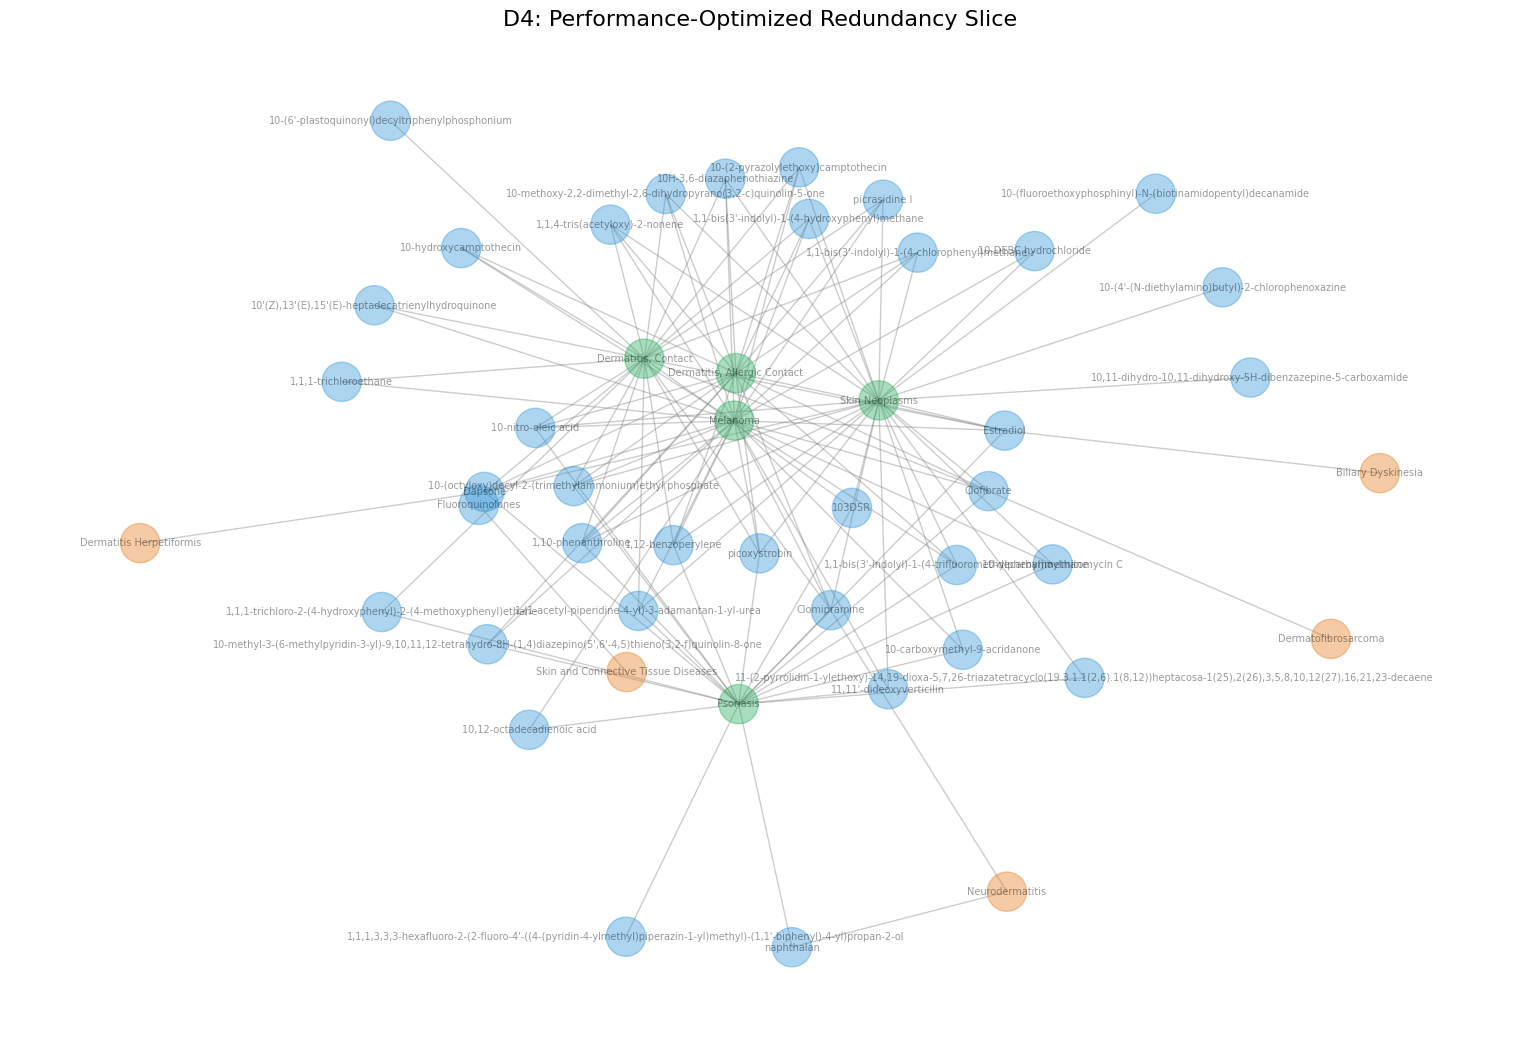

DELIVERABLE 4: SYSTEM REDUNDANCY AUDIT

 Found 9 High-Risk 'Brittle' Conditions (Degree <= 2).
Condition Name                      | Degree  | Primary Dependency
Dermatitis, Perioral                | 2       | Adrenal Cortex Hormones, azelaic acid
Klatskin Tumor                      | 2       | Azathioprine, Methotrexate
Acne, Adult                         | 0       | 
Radiodermatitis                     | 2       | Castor Oil, Peruvian balsam
Dermatofibrosarcoma                 | 1       | Clofibrate
Neurodermatitis                     | 2       | Clomipramine, naphthalan
Dermatitis Herpetiformis            | 1       | Dapsone
Biliary Dyskinesia                  | 1       | Estradiol
Skin and Connective Tissue Disease  | 1       | Fluoroquinolones

TOP 5 ROBUST 'SAFETY NET' CONDITIONS
 Melanoma                            | Degree: 6473
 Psoriasis                           | Degree: 6039
 Dermatitis, Allergic Contact        | Degree: 5804
 Skin Neoplasms                      | Degree: 

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_d4(G, top_k=5, bottom_k=5, neighbor_limit=15):
    conds = [n for n, v in G.nodes(data=True) if str(v.get('label')).lower() == 'condition']
    
    redundancy_map = {}
    for c in conds:
        subs = [nbr for nbr in G.neighbors(c) if str(G.nodes[nbr].get('label')).lower() == 'substance']
        if subs:
            redundancy_map[c] = subs

    sorted_conds = sorted(redundancy_map, key=lambda k: len(redundancy_map[k]), reverse=True)
    high_redun = sorted_conds[:top_k]
    low_redun = sorted_conds[-bottom_k:]
    selected_conds = high_redun + low_redun
    
    plot_nodes = list(selected_conds)
    for c in selected_conds:
        plot_nodes.extend(redundancy_map[c][:neighbor_limit])
    
    subgraph = G.subgraph(set(plot_nodes)) 
    
    plt.figure(figsize=(15, 10))
    pos = nx.kamada_kawai_layout(subgraph)
    
    node_colors = []
    for n in subgraph.nodes():
        if n in high_redun: node_colors.append('#27ae60') # Robust
        elif n in low_redun: node_colors.append('#e67e22') # Brittle
        else: node_colors.append('#3498db') # Treatment
            
    nx.draw(subgraph, pos, node_color=node_colors, 
            with_labels=True, labels={n: G.nodes[n].get('name', n) for n in subgraph.nodes()},
            node_size=800, font_size=7, edge_color='gray', alpha=0.4)
    
    plt.title("D4: Performance-Optimized Redundancy Slice", fontsize=16)
    plt.show()

plot_d4(G_loaded)

def audit_d4_vulnerabilities(G):
    print("DELIVERABLE 4: SYSTEM REDUNDANCY AUDIT\n")
    
    conds = [n for n, v in G.nodes(data=True) if str(v.get('label')).lower() == 'condition']
    brittle_nodes = [c for c in conds if G.degree(c) <= 2]
    
    print(f" Found {len(brittle_nodes)} High-Risk 'Brittle' Conditions (Degree <= 2).")
    print(f"{'Condition Name':<35} | {'Degree':<7} | {'Primary Dependency'}")
    
    for node_id in brittle_nodes[:20]: 
        name = G.nodes[node_id].get('name', 'Unknown')
        degree = G.degree(node_id)
        
        neighbors = list(G.neighbors(node_id))
        dependency_names = [G.nodes[nbr].get('name', nbr) for nbr in neighbors]
        dependency_str = ", ".join(dependency_names)
        
        print(f"{name[:34]:<35} | {degree:<7} | {dependency_str}")

    print("\nTOP 5 ROBUST 'SAFETY NET' CONDITIONS")
    robust_nodes = sorted(conds, key=lambda n: G.degree(n), reverse=True)[:5]
    for node_id in robust_nodes:
        name = G.nodes[node_id].get('name', 'Unknown')
        print(f" {name:<35} | Degree: {G.degree(node_id)}")

audit_d4_vulnerabilities(G_loaded)